# Modelización Matemática - Tema 1
## Diego Ángel Gallardo Costilla

### Preámbulo (Ejercicios 2.3 y 2.4)
Para comenzar, importaremos la librería **pandas** y procederemos a importar nuestra base de datos `PContexto.txt` fabricada en **ConExp**. Para hacerlo, nos valdremos del siguiente script, modificado para convertir los nombres de los objetos:

In [2]:
import pandas as pd

#Convertimos el archivo.txt a .csv
read_file = pd.read_csv ('PContexto.txt', delimiter = '\t')
read_file.to_csv ('PContexto.csv', index=False, sep = ';')

In [3]:
#Convertimos el archivo .csv a dataframe (para poder manipularlo y añadir la etiqueta de los objetos)
df = pd.read_csv ('PContexto.csv', sep = ';') 

#Eliminamos la útlima columna de la tabla (dado que contiene NaN)
df = df.drop(df.columns[df.shape[1]-1], axis=1)


#Definimos el nombre que le queremos dar a cada objeto (que se corresponde con las fila de nuestro nuevo dataframe).
#objetos =[]
#for i in range(0,df.shape[0]):
#    objetos.append('Obj '+ str(i+1))
    
#Otra posibilidad es introducir a mano el nombre de los objetos como:
objetos =["Special Week","Silence Suzuka","Daiwa Scarlet","Vodka","Gold Ship","Mejiro McQueen","Tokai Teio","Symboli Rudolf","Biwa Hayahide","Narita Brian","Eishin Flash","Hishi Akebono","Tamamo Cross","Haru Urara","Oguri Cap"]

#Insertamos el nombre de los objetos por cada fila
df.insert(0, "", objetos, True) 

#Volvemos a convertir el dataframe en archivo .csv
df.to_csv('ContextoLimpio.csv', index=False, sep=';')

Una vez convertida y nombrada `ContextoLimpio.csv`, es hora de leerla con **pandas** y asignarle `df` para poder trabajar con ella en los siguientes ejercicios.

In [4]:
df = pd.read_csv("ContextoLimpio.csv", sep=";", index_col=0)

Esta base de datos contiene información sobre caballos de carreras japoneses: sus aptitudes de pista, longitudes, estilos de carrera y destrezas. Para la comprensión del lector, "Turf" y "Dirt" son sus aptitudes de pista, las cuatro longitudes van de "Sprint" a "Long", los cuatro estilos van de "End Closer" a "Front Runner" y los últimos cinco atributos son sus destrezas.

In [5]:
df

,Turf,Dirt,Sprint,Mile,Medium,Long,End Closer,Late Surger,Pace Chaser,Front Runner,Speed Bonus,Stamina Bonus,Power Bonus,Guts Bonus,Wit Bonus
Special Week,1,0,0,0,1,1,0,1,1,0,0,1,0,0,1
Silence Suzuka,1,0,0,1,1,0,0,0,0,1,1,0,0,1,0
Daiwa Scarlet,1,0,0,1,1,0,0,0,1,1,1,0,0,1,0
Vodka,1,0,0,1,1,0,0,1,1,0,1,0,0,0,0
Gold Ship,1,0,0,0,1,1,1,1,1,0,0,1,1,0,0
Mejiro McQueen,1,0,0,0,1,1,0,0,1,0,0,1,0,0,1
Tokai Teio,1,0,0,0,1,1,0,0,1,0,1,1,0,1,0
Symboli Rudolf,1,0,0,0,1,1,0,1,1,0,0,1,0,1,0
Biwa Hayahide,1,0,0,0,1,1,0,1,1,0,0,0,0,1,1
Narita Brian,1,0,0,1,1,1,0,1,1,0,1,1,0,0,0


In [6]:
#El número de filas se nos determinará como df.shape[0], y el número de columnas como df.shape[1]. Veamos el nombre de los objetos:
print(df.index)

Index(['Special Week', 'Silence Suzuka', 'Daiwa Scarlet', 'Vodka', 'Gold Ship',
       'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide',
       'Narita Brian', 'Eishin Flash', 'Hishi Akebono', 'Tamamo Cross',
       'Haru Urara', 'Oguri Cap'],
      dtype='object')


In [7]:
print(df.iloc[2,0])
print(df.loc["Daiwa Scarlet","Turf"])

1
1


In [8]:
df_ext = df[(df["Turf"] == 1) & (df["Mile"] == 1) & (df["Guts Bonus"] == 1)]
df_ext

,Turf,Dirt,Sprint,Mile,Medium,Long,End Closer,Late Surger,Pace Chaser,Front Runner,Speed Bonus,Stamina Bonus,Power Bonus,Guts Bonus,Wit Bonus
Silence Suzuka,1,0,0,1,1,0,0,0,0,1,1,0,0,1,0
Daiwa Scarlet,1,0,0,1,1,0,0,0,1,1,1,0,0,1,0
Hishi Akebono,1,0,1,1,0,0,0,0,1,1,0,0,1,1,0


### Ejercicio 2.6

Sea $(\mathcal{O}, \mathcal{P}, \mathcal{R})$ nuestro contexto, expresado como DataFrame. A continuación, definiremos la **extensión** de un subconjunto $A \subseteq \mathcal{P}$ como operador de derivación en Python. En efectos prácticos, si introducimos una lista de atributos, nos devolverá los objetos que posean todos esos atributos a la vez.

In [9]:
def extension(df, atributos):
    """Dado un DataFrame y una lista de atributos, 
    devuelve solo los objetos que poseen 
    todos los atributos especificados."""
    if not atributos:
        return df.index.tolist()
    for atributo in atributos:
        if atributo in df.columns:
            df = df[df[atributo] == 1]
        else:
            print(f"El atributo '{atributo}' no se encuentra en el DataFrame.")
    return df.index.tolist()

Pongamos un ejemplo: queremos saber qué caballos corren en "Turf", a distancia "Mile" y se categorizan con "Guts Bonus". Usando la nueva función, los resultados concuerdan con la base de datos:

In [10]:
atributos = ["Turf", "Mile", "Guts Bonus"]
objetos_con_atributos = extension(df, atributos)
print(objetos_con_atributos)

['Silence Suzuka', 'Daiwa Scarlet', 'Hishi Akebono']


En **ConExp**, vemos que coinciden los resultados (el nodo que se encuentra más al sur es la extensión del conjunto):

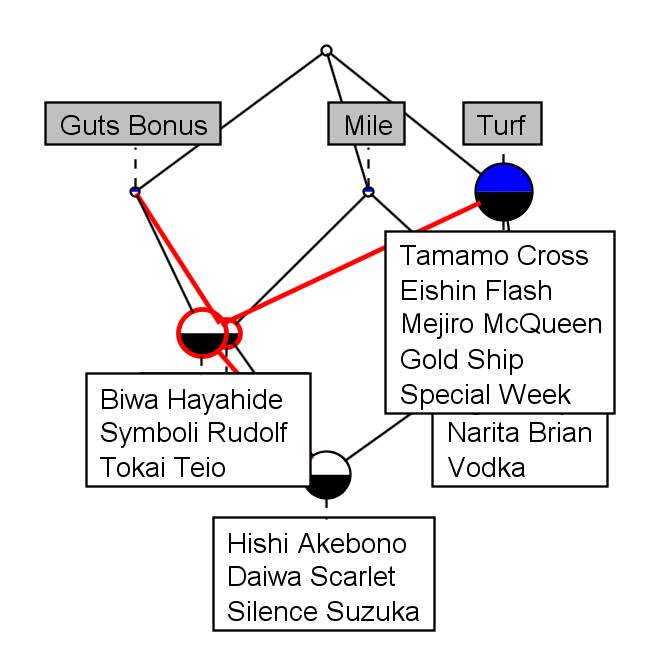

Ahora definiremos de forma similar el operador de derivación conocido como **intensión**, aplicado sobre un subconjunto $A \subseteq \mathcal{O}$. Si le introducimos una lista de objetos, nos devolverá los atributos que poseen todos en común.

In [11]:
def intension(df, objetos):
    """Dado un DataFrame y una lista de objetos, 
    devuelve solo los atributos que todos los objetos 
    especificados poseen."""
    filasobjetos = []
    for objeto in objetos:
        if objeto in df.index:
            # Extrae la fila completa del objeto y la añade a la lista de filasobjetos
            filasobjetos.append(df.loc[df.index == objeto])
        else:
            print(f"El objeto '{objeto}' no se encuentra en el DataFrame.")
    if not filasobjetos:
        return df.columns.tolist()  # Si no se encontraron objetos, devolvemos todos los atributos
    # Concatenamos todas las filas de filasobjetos en un solo DataFrame
    dfobj = pd.concat(filasobjetos)
    # Seleccionamos solo las columnas donde todos los valores son 1, es decir, los atributos comunes a todos los objetos
    atributos_comunes = dfobj.columns[(dfobj == 1).all()]
    return atributos_comunes.tolist()

Ahora, pongamos que queremos saber qué características de nuestra base de datos comparten "Gold Ship" y "Haru Urara". Al introducir la lista de nombres, obtendremos el resultado esperado.

In [12]:
objetos = ["Gold Ship", "Haru Urara"]
atributos_comunes = intension(df, objetos)
print(atributos_comunes)

['End Closer', 'Late Surger', 'Power Bonus']


Al comparar los resultados en **ConExp**, vemos que coinciden de forma satisfactoria (el nodo más al norte es la intensión).

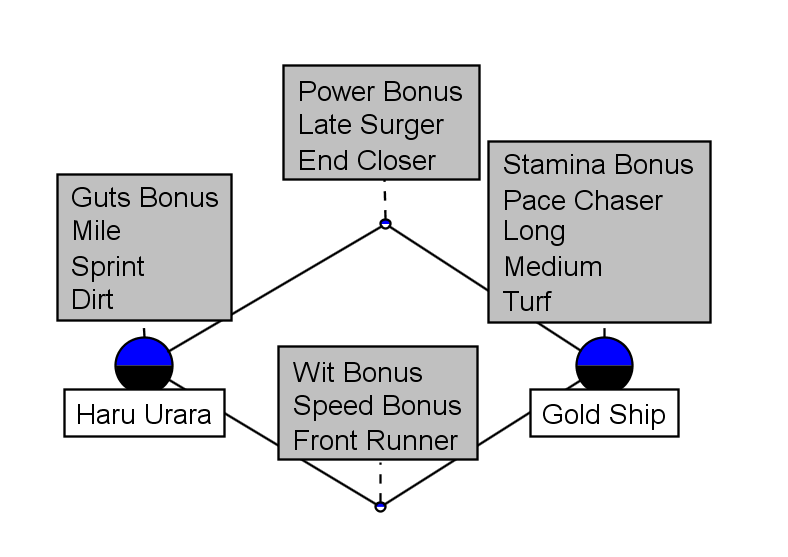

### Ejercicio 2.9

Ahora, comprobaremos si la composición de ambos operadores por ambos sentidos (por simplicidad consideremos a cualquiera de los dos como $c$) es un operador de clausura. Primero, definamos `intext` y `extint` como ambos sentidos de la composición. `intext` primero realiza la intensión y después la extensión, y `extint` viceversa.

In [13]:
def intext(df, objetos):
    return extension(df, intension(df, objetos))
def extint(df, atributos):
    return intension(df, extension(df, atributos))

Tomamos la relación de orden $\subseteq$ como la inclusión de conjuntos; para ver que `intext` y `extint` son crecientes, tomemos dos listas $l_i, l_ip$ tales que $l_i \subseteq l_ip$ y veamos que se mantiene $c(l_i) \subseteq c(l_ip)$:

In [14]:
l1 = ["Daiwa Scarlet", "Vodka"]
l1p = ["Daiwa Scarlet", "Vodka", "Haru Urara"]
l2 = ["Turf", "Long"]
l2p = ["Turf", "Long", "Guts Bonus"]
print(f"Realizamos la operación de extensión de la intensión de {l1} y {l1p}:")
print(f"Bien, se ve que {intext(df, l1)} está contenida en {intext(df, l1p)}")
print(f"Realizamos la operación de intensión de la extensión de {l2} y {l2p}:")
print(f"A su vez, se observa que {extint(df, l2)} está contenida en {extint(df, l2p)}")

Realizamos la operación de extensión de la intensión de ['Daiwa Scarlet', 'Vodka'] y ['Daiwa Scarlet', 'Vodka', 'Haru Urara']:
Bien, se ve que ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap'] está contenida en ['Silence Suzuka', 'Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Hishi Akebono', 'Haru Urara', 'Oguri Cap']
Realizamos la operación de intensión de la extensión de ['Turf', 'Long'] y ['Turf', 'Long', 'Guts Bonus']:
A su vez, se observa que ['Turf', 'Medium', 'Long', 'Pace Chaser'] está contenida en ['Turf', 'Medium', 'Long', 'Pace Chaser', 'Guts Bonus']


Comprobamos, usando esas mismas listas, que ambas cumplen que $x \subseteq c(x)$:

In [15]:
print(f"Se ve que {l1} está contenida en {intext(df, l1)}")
print(f"Se ve que {l2} está contenida en {extint(df, l2)}")

Se ve que ['Daiwa Scarlet', 'Vodka'] está contenida en ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap']
Se ve que ['Turf', 'Long'] está contenida en ['Turf', 'Medium', 'Long', 'Pace Chaser']


Por último, comprobemos que $c(c(x)) = c(x)$ de las dos formas:

In [16]:
cl1 = intext(df, l1)
cl2 = extint(df, l2)
ccl1 = intext(df, cl1)
ccl2 = extint(df, cl2)
print(f"Se ve que {cl1} es igual a {ccl1}")
print(f"Se ve que {cl2} es igual a {ccl2}")

Se ve que ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap'] es igual a ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap']
Se ve que ['Turf', 'Medium', 'Long', 'Pace Chaser'] es igual a ['Turf', 'Medium', 'Long', 'Pace Chaser']


### Ejercicio 2.10

Comprobemos que $\uparrow\downarrow$ y $\downarrow\uparrow$ son operadores de clausura. Veamos que ambas aplicaciones son crecientes; tomemos $x_1, x_2 \in P_2$ tales que $x_1 \leq_1 x_2$. Efectivamente, como $\uparrow$ es decreciente, $x_2^{\uparrow} \leq_2 x_1^{\uparrow}$, y como $\downarrow$ es decreciente, $x_1^{\uparrow\downarrow} \leq_1 x_2^{\uparrow\downarrow}$ (el razonamiento es análogo para $\downarrow\uparrow$). Que $x \leq_1 x^{\uparrow\downarrow}$ o su caso análogo es trivial por ser conexiones de Galois. Ahora, veamos que son idempotentes. Como $x \leq_1 x^{\uparrow\downarrow}$, se cumple que $x^{\uparrow\downarrow} \leq_1 (x^{\uparrow\downarrow})^{\uparrow\downarrow}$. Ahora bien, por la propiedad 2 se tiene que $x^{\uparrow} \leq_2 x^{\uparrow\downarrow\uparrow}$, y al ser $\downarrow$ decreciente, se tendrá pues que $x^{\uparrow\downarrow\uparrow\downarrow} \leq_1  x^{\uparrow\downarrow}$, como queríamos. De nuevo, el razonamiento es análogo para $\downarrow\uparrow$.$$\blacksquare$$

### Ejercicio 2.12
Procedamos a comprobar las propiedades del Lema 2.11. Para **1.** $X \subseteq X''$, $A \subseteq A''$, tomemos dos conjuntos en $\mathcal{O}$ y $\mathcal{P}$ y usemos las funciones `extint` y `intext` programadas anteriormente:

In [17]:
X = ["Daiwa Scarlet", "Vodka"]
A = ["Turf", "Long"]
print(f"Se ve que {X} está contenida en {intext(df, X)}")
print(f"Se ve que {A} está contenida en {extint(df, A)}")

Se ve que ['Daiwa Scarlet', 'Vodka'] está contenida en ['Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Oguri Cap']
Se ve que ['Turf', 'Long'] está contenida en ['Turf', 'Medium', 'Long', 'Pace Chaser']


**2.** Si $X_1 \subseteq X_2$, entonces $X_2' \subseteq X_1'$. Veamos:

In [18]:
X1 = ["Daiwa Scarlet", "Vodka"]
X2 = ["Daiwa Scarlet", "Vodka", "Haru Urara"]
X2p = intension(df, X2)
X1p = intension(df, X1)
print(f"Se ve que {X2p} está contenida en {X1p}")

Se ve que ['Mile'] está contenida en ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Speed Bonus']


Análogamente, si $A_1 \subseteq A_2$, entonces $A_2' \subseteq A_1'$.

In [19]:
A1 = ["Turf", "Long"]
A2 = ["Turf", "Long", "Wit Bonus"]
A2p = extension(df, A2)
A1p = extension(df, A1)
print(f"Se ve que {A2p} está contenida en {A1p}")

Se ve que ['Special Week', 'Mejiro McQueen', 'Biwa Hayahide', 'Eishin Flash'] está contenida en ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross']


**3.** $X' = X'''$, $A' = A'''$. Usando los conjuntos del anterior:

In [20]:
print(f"{X1p} es igual a {extint(df, X1p)}")
print(f"A su vez, {A1p} es igual a {intext(df, A1p)}")

['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Speed Bonus'] es igual a ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Speed Bonus']
A su vez, ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross'] es igual a ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross']


**4.** $\left( \bigcup_{j \in J} X_j \right)' = \bigcap_{j \in J} X_j'$, $\left( \bigcup_{j \in J} A_j \right)' = \bigcap_{j \in J} A_j'$.

Primero, investiguemos cómo realizar intersecciones y uniones de listas.

In [21]:
x1 = ["Gold Ship", "Mejiro McQueen"]
x2 = ["Mejiro McQueen", "Daiwa Scarlet"]
x3 = ["Gold Ship", "Daiwa Scarlet", "Vodka"]
#La intersección de listas en Python se puede realizar mediante la función set() y el operador &:
int1 = list(set(x1) & set(x2))
int2 = list(set(x1) & set(x3))
int3 = list(set(x2) & set(x3))
print(f"La intersección de 1 y 2 es: {int1}")
print(f"La intersección de 1 y 3 es: {int2}")
print(f"La intersección de 2 y 3 es: {int3}")
# La unión de listas se puede realizar mediante el operador |:
union = list(set(x1) | set(x2) | set(x3))
print(f"Esta es la unión de las tres listas: {union}")

La intersección de 1 y 2 es: ['Mejiro McQueen']
La intersección de 1 y 3 es: ['Gold Ship']
La intersección de 2 y 3 es: ['Daiwa Scarlet']
Esta es la unión de las tres listas: ['Gold Ship', 'Vodka', 'Daiwa Scarlet', 'Mejiro McQueen']


Ahora, comprobemos la propiedad:

In [22]:
du = intension(df, union)
dx1 = intension(df, x1)
dx2 = intension(df, x2)
dx3 = intension(df, x3)
intd = list(set(dx1) & set(dx2) & set(dx3))
print(f"La propiedad se cumple: {intd} es igual a {du}.")

La propiedad se cumple: ['Pace Chaser', 'Medium', 'Turf'] es igual a ['Turf', 'Medium', 'Pace Chaser'].


Usando conjuntos de atributos en $\mathcal{P}$ y `extension`, se dará de forma análoga la segunda propiedad.

**5.** $X \subseteq A'$ si y sólo si $A \subseteq X'$.

Para la primera dirección, tomemos un conjunto $A \subseteq \mathcal{O}$ y un conjunto $X \subseteq \mathcal{P}$ tal que $X \subseteq A'$.

In [23]:
A = ["Biwa Hayahide", "Narita Brian"]
Ap = intension(df, A)
X = ["Turf", "Medium", "Long", "Pace Chaser"]
Xp = extension(df, X)
print(f"Bien, tomamos {X}, que está contenido en {Ap}")
print(f"Realizamos su extensión y obtenemos {Xp}.")
print(f"Se observa entonces que {A} está contenida en {Xp}")

Bien, tomamos ['Turf', 'Medium', 'Long', 'Pace Chaser'], que está contenido en ['Turf', 'Medium', 'Long', 'Late Surger', 'Pace Chaser']
Realizamos su extensión y obtenemos ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross'].
Se observa entonces que ['Biwa Hayahide', 'Narita Brian'] está contenida en ['Special Week', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross']


La segunda dirección será idéntica: tomamos un conjunto $X \subseteq \mathcal{P}$ y un conjunto $A \subseteq \mathcal{O}$ tal que $A \subseteq X'$.

In [24]:
X = ["Turf", "Mile"]
Xp = extension(df, X)
A = ["Hishi Akebono", "Oguri Cap"]
Ap = intension(df, A)
print(f"Bien, tomamos {A}, que está contenido en {Xp}")
print(f"Realizamos su intensión y obtenemos {Ap}.")
print(f"Se observa entonces que {X} está contenida en {Ap}")

Bien, tomamos ['Hishi Akebono', 'Oguri Cap'], que está contenido en ['Silence Suzuka', 'Daiwa Scarlet', 'Vodka', 'Narita Brian', 'Hishi Akebono', 'Oguri Cap']
Realizamos su intensión y obtenemos ['Turf', 'Mile', 'Pace Chaser', 'Power Bonus'].
Se observa entonces que ['Turf', 'Mile'] está contenida en ['Turf', 'Mile', 'Pace Chaser', 'Power Bonus']


### Ejercicio 2.13

Queremos ver si $\left( \bigcap_{j \in J} X_j \right)' = \bigcup_{j \in J} X_j'$. De nuevo, reutilizamos las listas del apartado **4.**.

In [25]:
inttotal = list(set(x1) & set(x2) & set(x3))
inttotald = intension(df, inttotal)
unionder = list(set(dx1) | set(dx2) | set(dx3))
print(f"Se observa que la intersección de las tres listas es {inttotal}, y su intensión es el conjunto completo.")
print(f"Se observa que la unión de las intensiones de las tres listas es {unionder}; NO es el conjunto completo.")

Se observa que la intersección de las tres listas es [], y su intensión es el conjunto completo.
Se observa que la unión de las intensiones de las tres listas es ['Pace Chaser', 'Stamina Bonus', 'Medium', 'Long', 'Turf']; NO es el conjunto completo.


### Ejercicio 2.17
Para este ejercicio, se nos solicita trabajar con el contexto $(\mathcal{O}, \mathcal{P}, \mathcal{R)}$ del Ejemplo 2.2. Para poder hacerlo en Python, necesitamos importarlo como archivo `.csv`. En la carpeta se halla el documento `EjemploPeces.txt`, y mediante una rápida modificación del **Script-txtConexp-csvPython** para poder conservar los índices, convertimos el contexto y lo importamos como `PecesLimpio.csv`.

In [26]:
dfpeces = pd.read_csv("PecesLimpio.csv", sep=";", index_col=0)
dfpeces

,fluvial,litoral,oceano
carpa,1,0,0
escatofagus,1,1,0
sargo,0,1,1
dorada,0,1,1
anguila,1,1,1


Tras importar nuestro contexto, se nos solicita encontrar los conceptos contenidos. Esto es, encontrar los pares $(X,A)$ con $X \subseteq \mathcal{O}$ y $A \subseteq \mathcal{P}$ tales que $X' = A$ y $A' = X$. Ahora bien, comprobando manualmente y siguiendo la notación del documento, para el contexto $(\mathcal{O}, \mathcal{P}, \mathcal{R})$, tenemos los siguientes conceptos:
$$
\begin{aligned}
C_1 &= (\mathcal{O}, \emptyset) \\
C_2 &= (\{\text{carpa, escatofagus, anguila}\}, \{\text{fluvial}\}) \\
C_3 &= (\{\text{escatofagus, sargo, dorada, anguila}\}, \{\text{litoral}\}) \\
C_4 &= (\{\text{escatofagus, anguila}\}, \{\text{fluvial, litoral}\}) \\
C_5 &= (\{\text{sargo, dorada, anguila}\}, \{\text{litoral, océano}\}) \\
C_6 &= (\{\text{anguila}\}, \{\text{fluvial, litoral, océano}\})
\end{aligned}
$$

### Ejercicio 2.21
Observamos que $C_6 = (\{\text{anguila}\}, \{\text{fluvial, litoral, océano}\})$ se puede generar intersecando los objetos de $C_2$ y $C_5$ (sabiendo que la intersección de objetos es cerrada para conceptos), y realizando la intensión de este conjunto. Como se demostró en el Teorema 2.18, este es considerado el **ínfimo** de ambos conjuntos. El **supremo** de otros conceptos se puede obtener intersecando los atributos: por ejemplo, la intersección de los conjuntos de atributos $A_2 = \{\text{fluvial}\}$ en $C_2$ y $A_4 = \{\text{fluvial, litoral}\}$ en $C_4$ es $A_2$. Por tanto, el ínfimo de $C_2$ y $C_4$ es el propio $C_2$.

### Ejercicio 2.22
Vamos a obtener un concepto nuevo a partir de otros dos de nuestro PContexto. 
Realizando derivaciones de dos conjuntos de objetos, obtuve dos conceptos: $C_1 = (\{\text{Gold Ship, Eishin Flash, Tamamo Cross, Haru Urara, Oguri Cap}\}, \{\text{Late Surger, Power Bonus}\})$ y $C_2 = (\{\text{Special Week, Gold Ship, Symboli Rudolf, Biwa Hayahide, Narita Brian, Eishin Flash, Tamamo Cross}\}, \{\text{Turf, Medium, Long, Late Surger, Pace Chaser}\})$. Recordando que la intersección de extensiones de conceptos da como resultado la extensión de otro concepto, las intersecamos.

In [27]:
C1 = [['Gold Ship', 'Eishin Flash', 'Tamamo Cross', 'Haru Urara', 'Oguri Cap'], ['Late Surger', 'Power Bonus']]
C2 = [['Special Week', 'Gold Ship', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Tamamo Cross'], ['Turf', 'Medium', 'Long', 'Late Surger', 'Pace Chaser']]
list(set(C1[0]) & set(C2[0]))

['Gold Ship', 'Eishin Flash', 'Tamamo Cross']

Operando la intensión de este conjunto, obtenemos un nuevo concepto $C_3= (X,A)$ (el cual verifica $X' = A$ y $A' = X$) de la misma forma que en el ejercicio anterior:

In [28]:
C3 = [list(set(C1[0]) & set(C2[0])), intension(df, list(set(C1[0]) & set(C2[0])))]
print(C3)
print(f"Se cumplen las propiedades de los conceptos: {set(extension(df, C3[1])) == set(C3[0])} y {set(intension(df, C3[0])) == set(C3[1])}.")

[['Gold Ship', 'Eishin Flash', 'Tamamo Cross'], ['Turf', 'Medium', 'Long', 'Late Surger', 'Pace Chaser', 'Power Bonus']]
Se cumplen las propiedades de los conceptos: True y True.


### Ejercicio 2.26
Hemos de programar las funciones $\gamma$ (objeto concepto) y $\mu$ (atributo concepto). Para ello, nos valdremos de las anteriores funciones de composición que definimos en ejercicios anteriores, `intext` y `extint`, para agrupar mejor el código.

In [29]:
def gamma(df,objeto):
    '''Devuelve el concepto generado
    por el objeto.'''
    x = intext(df,objeto)
    a = intension(df,objeto)
    return [x,a]

In [30]:
def mu(df,atributo):
    '''Devuelve el concepto generado
    por el atributo.'''
    a = extint(df,atributo)
    x = extension(df,atributo)
    return [x,a]

Probemos las dos funciones con un ejemplo sensillo.

In [31]:
objeto = ["Daiwa Scarlet"]
atributo = ["Dirt"]
print(f"El concepto generado por el objeto {objeto} es: {gamma(df, objeto)}")
print(f"El concepto generado por el atributo {atributo} es: {mu(df, atributo)}")
print(f"Por poner un ejemplo, se comprueba que {gamma(df, objeto)[1]} es {intension(df, gamma(df, objeto)[0])}.")

El concepto generado por el objeto ['Daiwa Scarlet'] es: [['Daiwa Scarlet'], ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Front Runner', 'Speed Bonus', 'Guts Bonus']]
El concepto generado por el atributo ['Dirt'] es: [['Haru Urara', 'Oguri Cap'], ['Dirt', 'Mile', 'Late Surger', 'Power Bonus']]
Por poner un ejemplo, se comprueba que ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Front Runner', 'Speed Bonus', 'Guts Bonus'] es ['Turf', 'Mile', 'Medium', 'Pace Chaser', 'Front Runner', 'Speed Bonus', 'Guts Bonus'].


### Ejercicio 2.27

El conjunto supremo denso $\gamma(\mathcal{O})$ que denota el Teorema 2.25 no es más que el conjunto de conceptos generados por cada objeto; ídem con el ínfimo denso $\mu(\mathcal{P})$, pero generado por los atributos. Generemos los conjuntos de forma sencilla con las funciones que acabamos de programar:

In [32]:
def supremo_denso(df):
    return [gamma(df, [x]) for x in df.index]
def infimo_denso(df):
    return [mu(df, [x]) for x in df.columns]

In [33]:
# Sin imprimir el resultado, dado que es muy largo
supremo_denso(df), infimo_denso(df)
print(f"Se observa que el supremo denso es el conjunto de conceptos generados por cada objeto, y el infimo denso es el conjunto de conceptos generados por cada atributo.")

Se observa que el supremo denso es el conjunto de conceptos generados por cada objeto, y el infimo denso es el conjunto de conceptos generados por cada atributo.


Bueno, para responder a la siguiente pregunta: sabemos que hay una relación, por ejemplo, entre $x = \text{"Biwa Hayahide"}$ en los objetos y $a = \text{"Pace Chaser"}$ en los atributos. Por tanto, veamos si $\gamma(x) \leq \mu(a)$:

In [34]:
x = ["Biwa Hayahide"]
a = ["Pace Chaser"]
c1 = gamma(df, x)
c2 = mu(df, a)
print(f"Veamos si {c1[0]} es subconjunto de {c2[0]}:")
print(set(c1[0]).issubset(set(c2[0])))

Veamos si ['Biwa Hayahide'] es subconjunto de ['Special Week', 'Daiwa Scarlet', 'Vodka', 'Gold Ship', 'Mejiro McQueen', 'Tokai Teio', 'Symboli Rudolf', 'Biwa Hayahide', 'Narita Brian', 'Eishin Flash', 'Hishi Akebono', 'Tamamo Cross', 'Oguri Cap']:
True


Por tanto, la tercera propiedad del teorema se cumple en el ejemplo proporcionado.

### Ejercicio 2.31

### Ejercicio 2.34
Comentando cada paso, he implementado el algoritmo del Paso 1 para hallar todos los conceptos.

In [35]:
def algoritmo(df):
    '''Dado un contexto, devuelve todos sus conceptos de forma "óptima" (o al menos como yo lo he intentado).'''
    conceptos = []
    objetos = df.index.tolist()
    atributos_restantes = [col for col in df.columns]
    
    # Empezamos definiendo el primer concepto, el formado por todos los objetos y los atributos comunes a todos ellos
    # A partir de ahí, se van generando nuevos conceptos a partir de los atributos con mayor extensión, y así sucesivamente
    atributos_primer_concepto = []
    # Para el primer concepto, solo se cogen aquellos atributos cuya extensión son todos los objetos
    for atributo in list(atributos_restantes):
        if len(extension(df, [atributo])) == len(objetos):
            atributos_primer_concepto.append(atributo)
            atributos_restantes.remove(atributo)
            
    conceptos.append([objetos, atributos_primer_concepto])
    
    # BUCLE PRINCIPAL
    while atributos_restantes:
        # Cogemos el atributo de mayor extensión de los que quedan
        atributo_max = max(atributos_restantes, key=lambda x: len(extension(df, [x])))
        objetos_nuevo = extension(df, [atributo_max])
        
        # Lo quitamos de la lista para que el while avance
        atributos_restantes.remove(atributo_max)
        
        # Empezamos la lista de nuevos conceptos que se van a generar en esta iteración, para luego añadirlos todos juntos al final de la iteración
        nuevos_conceptos_iteracion = []
        
        # Cruzamos la extensión de este nuevo atributo con TODOS los conceptos que ya teníamos
        for concepto in conceptos:
            # Intersecamos los objetos
            interseccion_obj = list(set(objetos_nuevo) & set(concepto[0]))
            
            # Para poder comparar listas de objetos fácilmente, es bueno ordenarlas
            interseccion_obj.sort()
            
            # Verificamos si esta intersección ha generado un grupo de objetos que NO teníamos antes
            conceptos_existentes = [sorted(c[0]) for c in conceptos]
            conceptos_nuevos = [sorted(c[0]) for c in nuevos_conceptos_iteracion]
            
            if interseccion_obj and (interseccion_obj not in conceptos_existentes) and (interseccion_obj not in conceptos_nuevos):
                # Como es un concepto nuevo, calculamos TODOS sus atributos (su intensión)
                atributos_interseccion = intension(df, interseccion_obj)
                nuevos_conceptos_iteracion.append([interseccion_obj, atributos_interseccion])
        
        # Añadimos los conceptos descubiertos en esta iteración a la lista global
        conceptos.extend(nuevos_conceptos_iteracion)
        
    return conceptos

In [36]:
algoritmo(dfpeces)

[[['carpa', 'escatofagus', 'sargo', 'dorada', 'anguila'], []],
 [['anguila', 'dorada', 'escatofagus', 'sargo'], ['litoral']],
 [['anguila', 'carpa', 'escatofagus'], ['fluvial']],
 [['anguila', 'escatofagus'], ['fluvial', 'litoral']],
 [['anguila', 'dorada', 'sargo'], ['litoral', 'oceano']],
 [['anguila'], ['fluvial', 'litoral', 'oceano']]]

\begin{aligned}
C_1 &= (\mathcal{O}, \emptyset) \\
C_2 &= (\{\text{carpa, escatofagus, anguila}\}, \{\text{fluvial}\}) \\
C_3 &= (\{\text{escatofagus, sargo, dorada, anguila}\}, \{\text{litoral}\}) \\
C_4 &= (\{\text{escatofagus, anguila}\}, \{\text{fluvial, litoral}\}) \\
C_5 &= (\{\text{sargo, dorada, anguila}\}, \{\text{litoral, océano}\}) \\
C_6 &= (\{\text{anguila}\}, \{\text{fluvial, litoral, océano}\})
\end{aligned}
$$

### Ejercicio 2.35
Incluyo una imagen de la Figura 2.9 para identificar los vértices:

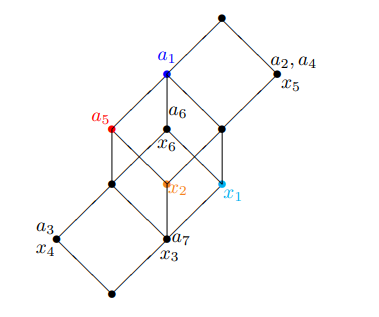

**Cian $x_1$**: Partiendo del "bottom", para hallar el concepto del vértice cian $x_1$ recorremos caminos ascendentes hasta el vértice cogiendo los objetos, obteniendo $\{x_3, x_1\}$. Hacemos lo mismo desde el "top" con los atributos, y recorriendo todos los caminos descendentes obtenemos $\{a_1, a_2, a_4, a_6\}$. Por ende, el concepto será ($\{x_3, x_1\}, \{a_1, a_2, a_4, a_6\}$).

**Naranja $x_2$**: Realizamos el mismo proceso con los objetos: obtenemos $\{x_3, x_2\}$. Ahora con los atributos: $\{a_1, a_2, a_4, a_5\}$. El concepto será, pues, $(\{x_3, x_2\}, \{a_1, a_2, a_4, a_5\})$.

**Rojo $a_5$**: Objetos: $\{x_4,x_3\}$. Atributos: $\{a_1, a_5\}$.

**Azul $a_1$**: Objetos: $\{x_4, x_3, x_2, x_1, x_6\}$. Atributos: $\{a_1\}$.

### Ejercicio 2.40
Primero, observemos que el número de conceptos en nuestro PContexto habitual es 61.

In [37]:
len(algoritmo(df))

60

Ahora, definamos un nuevo PContexto sin los dos primeros atributos (Turf y Dirt):

In [38]:
# DataFrame sin los dos primeros atributos
dfsin2p = df.drop(columns=df.columns[:2])
dfsin2p

,Sprint,Mile,Medium,Long,End Closer,Late Surger,Pace Chaser,Front Runner,Speed Bonus,Stamina Bonus,Power Bonus,Guts Bonus,Wit Bonus
Special Week,0,0,1,1,0,1,1,0,0,1,0,0,1
Silence Suzuka,0,1,1,0,0,0,0,1,1,0,0,1,0
Daiwa Scarlet,0,1,1,0,0,0,1,1,1,0,0,1,0
Vodka,0,1,1,0,0,1,1,0,1,0,0,0,0
Gold Ship,0,0,1,1,1,1,1,0,0,1,1,0,0
Mejiro McQueen,0,0,1,1,0,0,1,0,0,1,0,0,1
Tokai Teio,0,0,1,1,0,0,1,0,1,1,0,1,0
Symboli Rudolf,0,0,1,1,0,1,1,0,0,1,0,1,0
Biwa Hayahide,0,0,1,1,0,1,1,0,0,0,0,1,1
Narita Brian,0,1,1,1,0,1,1,0,1,1,0,0,0


Muy bien, el número de conceptos ahora será:

In [39]:
len(algoritmo(dfsin2p))

57

Observamos que el número de conceptos se ha visto reducido; debe de ser que alguno de nuestros dos atributos (o los dos) es absolutamente necesario para generar la misma cantidad de conceptos. Ahora, en el contexto de los peces, estos son los conceptos:

In [40]:
algoritmo(dfpeces)

[[['carpa', 'escatofagus', 'sargo', 'dorada', 'anguila'], []],
 [['anguila', 'dorada', 'escatofagus', 'sargo'], ['litoral']],
 [['anguila', 'carpa', 'escatofagus'], ['fluvial']],
 [['anguila', 'escatofagus'], ['fluvial', 'litoral']],
 [['anguila', 'dorada', 'sargo'], ['litoral', 'oceano']],
 [['anguila'], ['fluvial', 'litoral', 'oceano']]]

Quitémosle el atributo "océano", y observamos que obtenemos dos conceptos menos.

In [41]:
algoritmo(dfpeces.drop(columns="oceano"))

[[['carpa', 'escatofagus', 'sargo', 'dorada', 'anguila'], []],
 [['anguila', 'dorada', 'escatofagus', 'sargo'], ['litoral']],
 [['anguila', 'carpa', 'escatofagus'], ['fluvial']],
 [['anguila', 'escatofagus'], ['fluvial', 'litoral']]]

In [42]:
# Y si eliminamos el objeto "sargo":
algoritmo(dfpeces.drop(index="sargo"))

[[['carpa', 'escatofagus', 'dorada', 'anguila'], []],
 [['anguila', 'carpa', 'escatofagus'], ['fluvial']],
 [['anguila', 'dorada', 'escatofagus'], ['litoral']],
 [['anguila', 'escatofagus'], ['fluvial', 'litoral']],
 [['anguila', 'dorada'], ['litoral', 'oceano']],
 [['anguila'], ['fluvial', 'litoral', 'oceano']]]

El objeto "sargo" era absolutamente innecesario, ya que se han generado los mismos conceptos y el retículo es isomorfo al original.

### Ejercicio 2.41

### Ejercicio 2.47
Procedemos a realizar los atributo conceptos de "fluvial", "litoral" y "océano":

In [43]:
print(f"De fluvial: {mu(dfpeces, ['fluvial'])}. De litoral: {mu(dfpeces, ['litoral'])}. ")
print(f"De océano: {mu(dfpeces, ['oceano'])}")

De fluvial: [['carpa', 'escatofagus', 'anguila'], ['fluvial']]. De litoral: [['escatofagus', 'sargo', 'dorada', 'anguila'], ['litoral']]. 
De océano: [['sargo', 'dorada', 'anguila'], ['litoral', 'oceano']]


Hemos obtenido los siguientes conceptos:
$$C_2 = (\{\text{carpa, escatofagus, anguila}\}, \{\text{fluvial}\}) \\
C_3 = (\{\text{escatofagus, sargo, dorada, anguila}\}, \{\text{litoral}\}) \\
C_5 = (\{\text{sargo, dorada, anguila}\}, \{\text{litoral, océano}\})
$$
Intersecando las extensiones dos a dos, no obtenemos ningún concepto de esos tres cuya extensión no fuera igual a alguna de las dos que habían sido operadas en la intersección; es decir, todos los atributos pertenecen al núcleo $C_f$. Esto es, son absolutamente necesarios.



Ahora, toca clasificar los atributos de nuestro PContexto.

### Ejercicio 2.48

### Ejercicio 2.56

Primero, he definido una función nueva que comprueba según la Proposición 2.54 si una implicación es válida. Procedamos a analizar las proposiciones del ejercicio.

In [44]:
def es_valida(df, atributo1, atributo2):
    '''Dado un contexto y dos grupos de atributos, devuelve si el primero implica al segundo.'''
    atr1 = set(extint(df, atributo1))
    atr2 = set(atributo2)
    return atr2.issubset(atr1)

In [45]:
print(es_valida(dfpeces, ["oceano"], ["litoral"]))
print(es_valida(dfpeces, ["oceano"], ["litoral","fluvial"]))
print(es_valida(dfpeces, ["oceano"], ["fluvial"]))
print(es_valida(dfpeces, ["litoral"], ["oceano"]))
print(es_valida(dfpeces, ["fluvial","litoral"], ["oceano"]))
print(es_valida(dfpeces, ["oceano","litoral"], ["fluvial"]))
print(es_valida(dfpeces, ["fluvial","oceano"], ["litoral"]))

True
False
False
False
False
False
True


### Ejercicio 2.57

Llevando a cabo una serie de pruebas en nuestro PContexto para comprobar algunas implicaciones:

In [46]:
print(f"Se observa que 'Pace Chaser' implica 'Turf' ya que es {es_valida(df, ['Pace Chaser'], ['Turf'])}.")
print(f"Se observa que 'Turf' no implica 'Pace Chaser' ya que es {es_valida(df, ['Turf'], ['Pace Chaser'])}.")
print(f"Se observa que 'Speed Bonus' implica 'Medium' ya que es {es_valida(df, ['Speed Bonus'], ['Medium'])}.")
print(f"Se observa que 'Dirt' no implica 'Pace Chaser' ya que es {es_valida(df, ['Dirt'], ['Pace Chaser'])}.")
print(f"Se observa que 'Medium' implica 'Turf' ya que es {es_valida(df, ['Medium'], ['Turf'])}.")
print(f"Se observa que 'Turf' no implica 'Medium', 'Speed Bonus' ya que es {es_valida(df, ['Turf'], ['Medium','Speed Bonus'])}.")
print(f"Se observa que 'Turf', 'Late Surger' implica 'Medium' ya que es {es_valida(df, ['Turf','Late Surger'], ['Medium'])}.")
print(f"Se observa que 'Turf', 'Late Surger' no implica 'Speed Bonus' ya que es {es_valida(df, ['Turf','Late Surger'], ['Speed Bonus'])}.")
print(f"Se observa que 'Medium', 'Late Surger' implica 'Turf' ya que es {es_valida(df, ['Medium','Late Surger'], ['Turf'])}.")
print(f"Se observa que 'Dirt', 'Late Surger' no implica 'Turf' ya que es {es_valida(df, ['Dirt','Late Surger'], ['Turf'])}.")

Se observa que 'Pace Chaser' implica 'Turf' ya que es True.
Se observa que 'Turf' no implica 'Pace Chaser' ya que es False.
Se observa que 'Speed Bonus' implica 'Medium' ya que es True.
Se observa que 'Dirt' no implica 'Pace Chaser' ya que es False.
Se observa que 'Medium' implica 'Turf' ya que es True.
Se observa que 'Turf' no implica 'Medium', 'Speed Bonus' ya que es False.
Se observa que 'Turf', 'Late Surger' implica 'Medium' ya que es True.
Se observa que 'Turf', 'Late Surger' no implica 'Speed Bonus' ya que es False.
Se observa que 'Medium', 'Late Surger' implica 'Turf' ya que es True.
Se observa que 'Dirt', 'Late Surger' no implica 'Turf' ya que es False.


Veamos si $\mathcal{P}$ implica ${a_4}$, en nuestro caso ${a_4} := \text{"Mile"}$

In [47]:
print(f"Vemos, finalmente, que el conjunto de todos los atributos implica Mile: {es_valida(df, df.columns.to_list(), ['Mile'])}.")

Vemos, finalmente, que el conjunto de todos los atributos implica Mile: True.


### Ejercicio 2.64
La base de Duquenne-Guigues proporcionada por ConExp de nuestro PContexto es la siguiente:

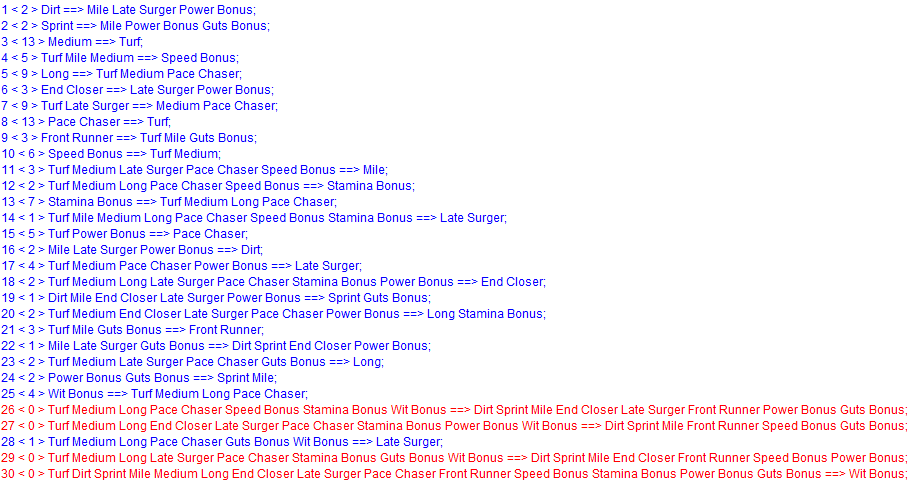

Las implicaciones válidas que poseíamos en el Ejercicio anterior son las siguientes:

In [48]:
print(f"Se observa que 'Pace Chaser' implica 'Turf' ya que es {es_valida(df, ['Pace Chaser'], ['Turf'])}.")
print(f"Se observa que 'Speed Bonus' implica 'Medium' ya que es {es_valida(df, ['Speed Bonus'], ['Medium'])}.")
print(f"Se observa que 'Medium' implica 'Turf' ya que es {es_valida(df, ['Medium'], ['Turf'])}.")
print(f"Se observa que 'Turf', 'Late Surger' implica 'Medium' ya que es {es_valida(df, ['Turf','Late Surger'], ['Medium'])}.")
print(f"Se observa que 'Medium', 'Late Surger' implica 'Turf' ya que es {es_valida(df, ['Medium','Late Surger'], ['Turf'])}.")

Se observa que 'Pace Chaser' implica 'Turf' ya que es True.
Se observa que 'Speed Bonus' implica 'Medium' ya que es True.
Se observa que 'Medium' implica 'Turf' ya que es True.
Se observa que 'Turf', 'Late Surger' implica 'Medium' ya que es True.
Se observa que 'Medium', 'Late Surger' implica 'Turf' ya que es True.


In [49]:
from graphviz import Source
def DibujarReticuloConceptos(ReticuloConceptos, etiquetas = False) -> Source:

    dot = 'graph ReticuloConceptos {\nrankdir = BT;\n'
    upper_bounds = {i: [j for j, y in enumerate(ReticuloConceptos) if set(x[0]).issubset(y[0]) and x != y] for i, x in enumerate(ReticuloConceptos)}
    parents = {i: [j for j in upper_bounds[i] if not any(j!= k and set(ReticuloConceptos[k][0]).issubset(ReticuloConceptos[j][0]) for k in upper_bounds[i])] for i in range(len(ReticuloConceptos))}
    if etiquetas:
        dot += '\n'.join(['"' + str(i) + '" [label = "' + str(ReticuloConceptos[i]) + '"]'  for i in range(len(ReticuloConceptos))]) + '\n'
    dot += '; '.join([f'"{i}" -- "{j}"'  for i in range(len(ReticuloConceptos)) for j in parents[i]]) + '\n}'
    return Source(dot)

ModuleNotFoundError: No module named 'graphviz'

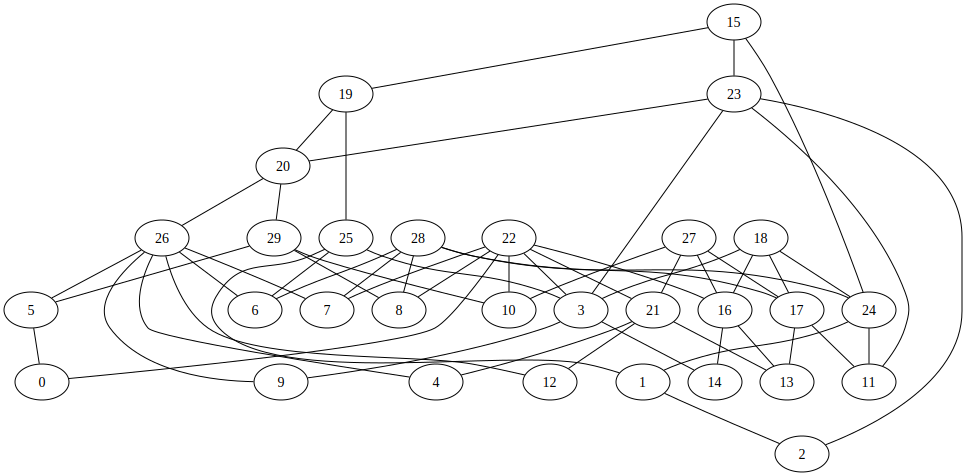

In [ ]:
CL = supremo_denso(df) + infimo_denso(df)
DibujarReticuloConceptos(CL)